In [ ]:
#@title 0) setup
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Causal Self-Attention from Scratch

In [ ]:
# size constants
batch_size = 1
sequence_length = 8
embedding_size = 8
head_dimension = 8     # dimension per head (= d_model for single-head)

In [ ]:
# 1. Inputs
x = torch.randn(batch_size, sequence_length, embedding_size)

# 2. Projection Matrices
W_q = torch.randn(embedding_size, head_dimension)
W_k = torch.randn(embedding_size, head_dimension)
W_v = torch.randn(embedding_size, head_dimension)

# 3. Project into Queries, Keys, Values
Q = x @ W_q
K = x @ W_k
V = x @ W_v

# 4. Scaled Dot-Product Attention Scores
scores = (Q @ K.transpose(-2, -1)) / math.sqrt(head_dimension)

# 5. Apply Causal Mask
mask = torch.triu(torch.ones(sequence_length, sequence_length), diagonal=1).bool()
scores = scores.masked_fill(mask, float("-inf"))

# 6. Softmax
attn_weights = F.softmax(scores, dim=-1)

# 7. Output
output = attn_weights @ V


In [ ]:
# --- Display Results ---
print(f"Input shape:  {x.shape}")
print(f"Q/K/V shape:  {Q.shape}")
print(f"Scores shape: {scores.shape}")
print(f"Output shape: {output.shape}\n")

print("Causal Mask (1 = blocked):")
print(mask.int())

print("\nAttention Weights (Batch 0):")
print(attn_weights[0].detach().numpy().round(3))

Input shape:  torch.Size([1, 8, 8])
Q/K/V shape:  torch.Size([1, 8, 8])
Scores shape: torch.Size([1, 8, 8])
Output shape: torch.Size([1, 8, 8])

Causal Mask (1 = blocked):
tensor([[0, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)

Attention Weights (Batch 0):
[[1.    0.    0.    0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.985 0.015 0.    0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.073 0.499 0.    0.378 0.049 0.    0.    0.   ]
 [0.492 0.    0.    0.    0.501 0.007 0.    0.   ]
 [0.001 0.001 0.939 0.001 0.001 0.013 0.044 0.   ]
 [0.893 0.    0.054 0.    0.036 0.    0.013 0.004]]


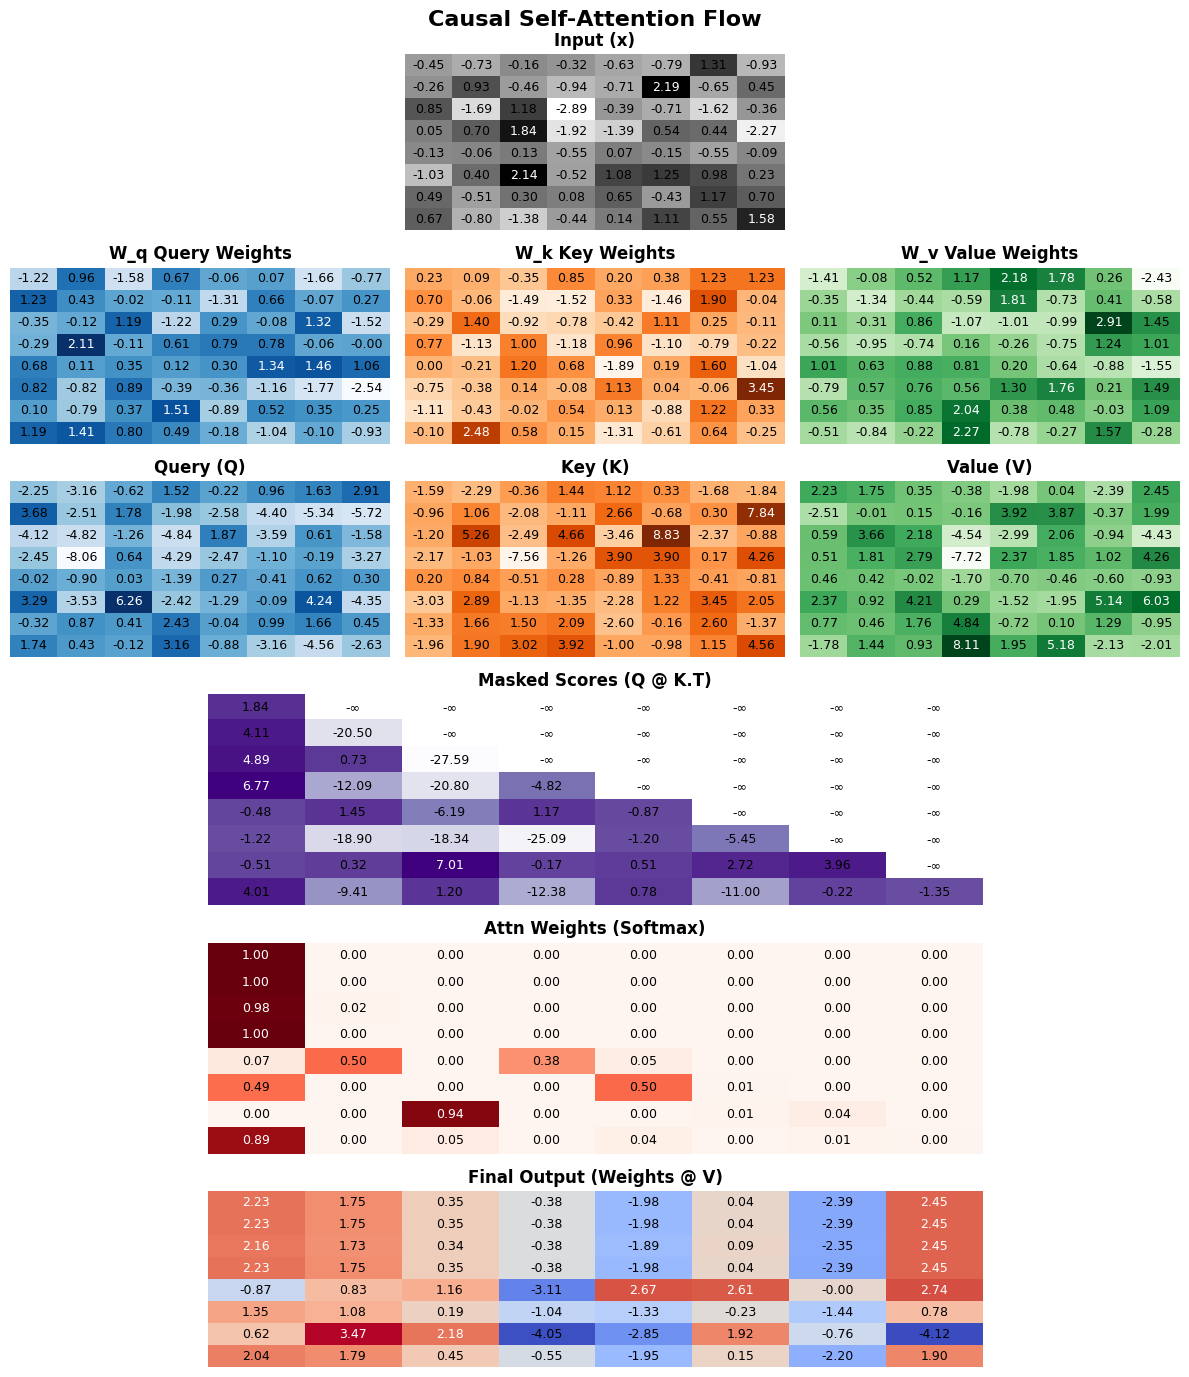

In [ ]:
#@title Visualize step-by-step causal self-attention

fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(6, 6, height_ratios=[1, 1, 1, 1.2, 1.2, 1])

# Define layout for the graph
ax_x = fig.add_subplot(gs[0, 2:4])

ax_Wq = fig.add_subplot(gs[1, 0:2])
ax_Wk = fig.add_subplot(gs[1, 2:4])
ax_Wv = fig.add_subplot(gs[1, 4:6])

ax_Q = fig.add_subplot(gs[2, 0:2])
ax_K = fig.add_subplot(gs[2, 2:4])
ax_V = fig.add_subplot(gs[2, 4:6])

ax_scores = fig.add_subplot(gs[3, 1:5])
ax_weights = fig.add_subplot(gs[4, 1:5])
ax_out = fig.add_subplot(gs[5, 1:5])

def plot_annotated(ax, tensor, title, cmap):
    # Handle 2D or 3D tensors safely
    if tensor.dim() == 3:
        mat = tensor[0].detach().numpy()
    else:
        mat = tensor.detach().numpy()

    # Handle -inf for color mapping
    mat_vis = np.where(np.isinf(mat), np.nan, mat)
    ax.imshow(mat_vis, cmap=cmap, aspect='auto')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    # Annotate with the exact numbers
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = "-∞" if np.isinf(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if (not np.isnan(val) and val > np.nanmax(mat_vis)*0.6) else "black",
                    fontsize=9)

# Plot each matrix
plot_annotated(ax_x, x, "Input (x)", "Greys")

plot_annotated(ax_Wq, W_q, "W_q Query Weights", "Blues")
plot_annotated(ax_Wk, W_k, "W_k Key Weights", "Oranges")
plot_annotated(ax_Wv, W_v, "W_v Value Weights", "Greens")

plot_annotated(ax_Q, Q, "Query (Q)", "Blues")
plot_annotated(ax_K, K, "Key (K)", "Oranges")
plot_annotated(ax_V, V, "Value (V)", "Greens")

plot_annotated(ax_scores, scores, "Masked Scores (Q @ K.T)", "Purples")
plot_annotated(ax_weights, attn_weights, "Attn Weights (Softmax)", "Reds")

plot_annotated(ax_out, output, "Final Output (Weights @ V)", "coolwarm")

fig.suptitle("Causal Self-Attention Flow", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 2) PyTorch Module


In [ ]:
class CausalSelfAttention(nn.Module):
    """Single-head causal (masked) self-attention."""

    def __init__(self, embedding_size: int, head_dimension: int, max_seq_len: int = 1024):
        super().__init__()
        self.head_dimension = head_dimension
        self.W_q = nn.Linear(embedding_size, head_dimension, bias=False)
        self.W_k = nn.Linear(embedding_size, head_dimension, bias=False)
        self.W_v = nn.Linear(embedding_size, head_dimension, bias=False)
        # register the mask as a buffer so it moves to GPU with .to(device)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool(),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.head_dimension)
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
        attn_weights = F.softmax(scores, dim=-1)
        output = attn_weights @ V
        return output, attn_weights

In [ ]:
class MultiHeadAttention(nn.Module):
    """Multi-head causal self-attention with an output projection."""

    def __init__(self, embedding_size: int, n_heads: int, max_seq_len: int = 1024):
        super().__init__()
        assert embedding_size % n_heads == 0, "embedding_size must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dimension = embedding_size // n_heads

        # one big linear then reshape is the efficient version;
        # we keep separate heads here for clarity
        self.heads = nn.ModuleList(
            [CausalSelfAttention(embedding_size, self.head_dimension, max_seq_len) for _ in range(n_heads)]
        )
        self.out_proj = nn.Linear(embedding_size, embedding_size, bias=False)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        head_outputs = [h(x) for h in self.heads]
        # concatenate the value outputs from every head
        out = torch.cat([o for o, _ in head_outputs], dim=-1)  # (B, T, embedding_size)
        # stack the attention maps so we can inspect per-head patterns
        attn = torch.stack([a for _, a in head_outputs], dim=1)  # (B, n_heads, T, T)
        return self.out_proj(out), attn

In [ ]:
# quick smoke test
n_heads = 4
mha = MultiHeadAttention(embedding_size=embedding_size, n_heads=n_heads)
x = torch.randn(batch_size, sequence_length, embedding_size)

out, attn = mha(x)
print(f"MHA output: {out.shape}  # (batch, sequence_length, embedding_size)")
print(f"Attn maps:  {attn.shape}  # (batch, n_heads, T, T)")

# each row should sum to 1 — it's a probability distribution
print(f"\nRow sums (should be 1.0): {attn[0, 0].sum(dim=-1).detach().numpy().round(4)}")

MHA output: torch.Size([1, 4, 8])  # (batch, sequence_length, embedding_size)
Attn maps:  torch.Size([1, 4, 4, 4])  # (batch, n_heads, T, T)

Row sums (should be 1.0): [1. 1. 1. 1.]


# 3) Mechanistic Interpretability: Attention in GPT-2, ad-hoc visualization

In [ ]:
from transformers import GPT2Tokenizer, GPT2Model

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", output_attentions=True).eval().to(device)

print(f"GPT-2 config: {model.config.n_layer} layers, {model.config.n_head} heads, d_model={model.config.n_embd}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 config: 12 layers, 12 heads, d_model=768


In [ ]:
# a sentence with clear syntactic structure for interpretability
prompt = "When Mary and John went to the store, John gave a drink to Mary."

inputs = tokenizer(prompt, return_tensors="pt").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions is a tuple of (1, n_heads, T, T) — one per layer
attentions = torch.cat(outputs.attentions, dim=0)  # (n_layers, n_heads, T, T)
print(f"Attention tensor: {attentions.shape}  # (layers, heads, query_pos, key_pos)")
print(f"Tokens: {tokens}")

Attention tensor: torch.Size([12, 12, 16, 16])  # (layers, heads, query_pos, key_pos)
Tokens: ['When', 'ĠMary', 'Ġand', 'ĠJohn', 'Ġwent', 'Ġto', 'Ġthe', 'Ġstore', ',', 'ĠJohn', 'Ġgave', 'Ġa', 'Ġdrink', 'Ġto', 'ĠMary', '.']


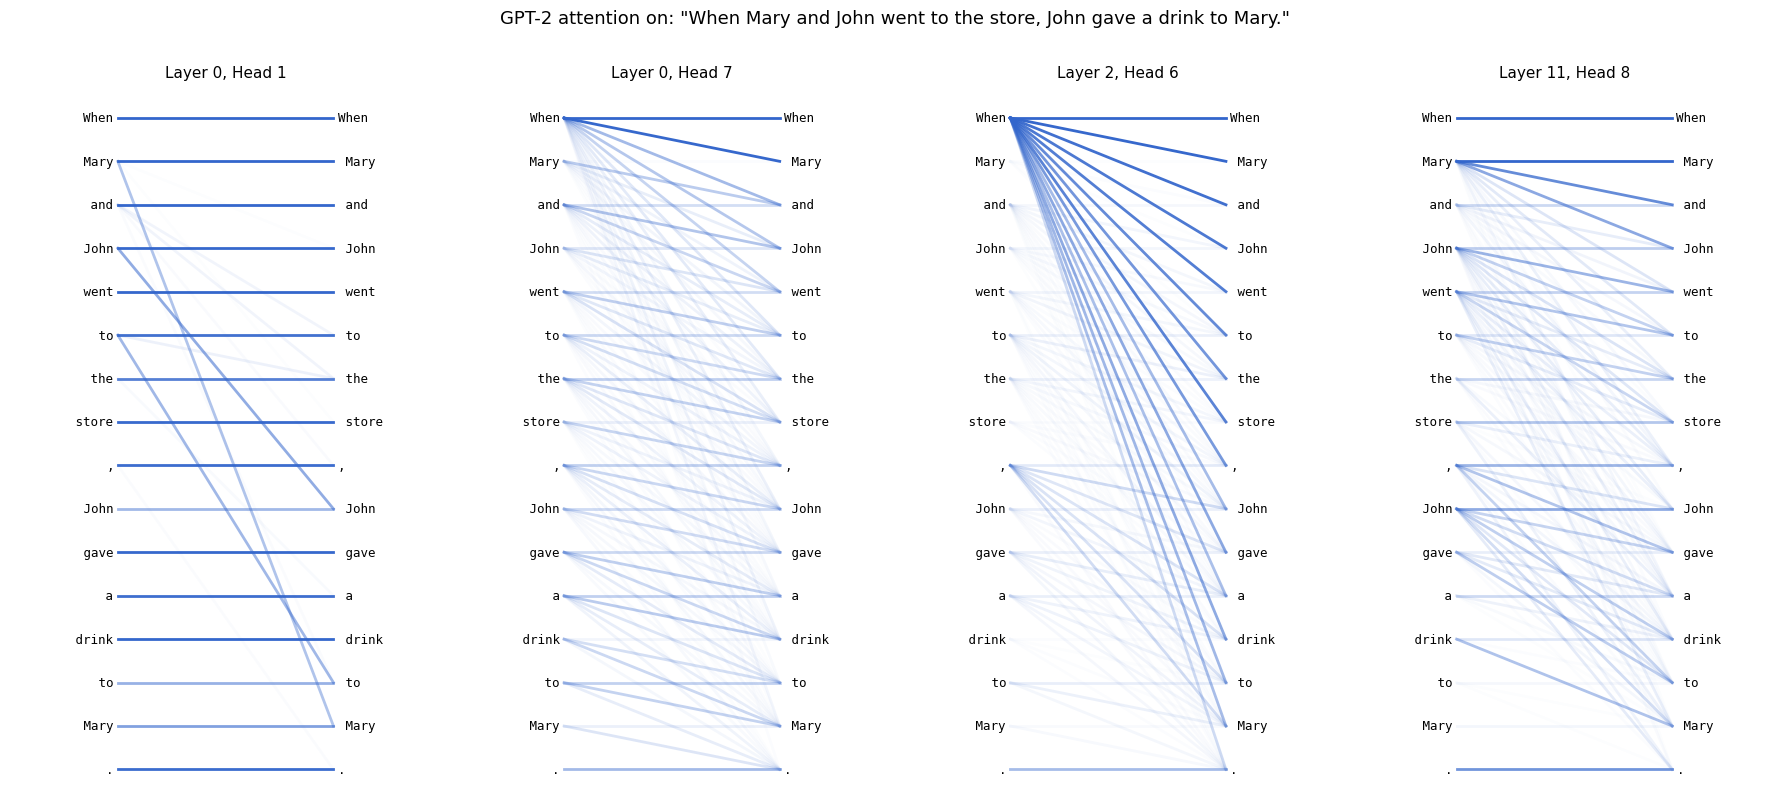

In [ ]:
#@title visualize interesting attention heads
interesting = [(0, 1), (0, 7), (2, 6), (11, 8)]

def plot_attention(attn, tokens, layer, head, ax=None):
    """
    Draws lines from every destination (query) token to every source (key)
    token, with opacity proportional to the attention weight. This makes
    it immediately visible which earlier tokens each position is attending to.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 8))

    weights = attn[layer, head].cpu().numpy()  # (T, T)
    n = len(tokens)

    # clean token labels
    labels = [t.replace("Ġ", " ").replace("Ċ", "\\n") for t in tokens]

    x_src, x_dst = 0.0, 1.0

    for i in range(n):
        y = 1 - i / (n - 1)  # top to bottom
        ax.text(x_src - 0.02, y, labels[i], ha="right", va="center", fontsize=9, fontfamily="monospace")
        ax.text(x_dst + 0.02, y, labels[i], ha="left", va="center", fontsize=9, fontfamily="monospace")

    for dst in range(n):
        for src in range(dst + 1):  # causal: src <= dst
            w = weights[dst, src]
            if w < 0.01:
                continue
            y_dst = 1 - dst / (n - 1)
            y_src = 1 - src / (n - 1)
            ax.plot(
                [x_src, x_dst], [y_src, y_dst],
                color="#3366cc", alpha=float(w), linewidth=2,
            )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.05, 1.05)
    ax.axis("off")
    ax.set_title(f"Layer {layer}, Head {head}", fontsize=11)


# show a few interesting heads in GPT-2
fig, axes = plt.subplots(1, 4, figsize=(18, 8))
for ax, (l, h) in zip(axes, interesting):
    plot_attention(attentions, tokens, l, h, ax=ax)
fig.suptitle(f'GPT-2 attention on: "{prompt}"', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

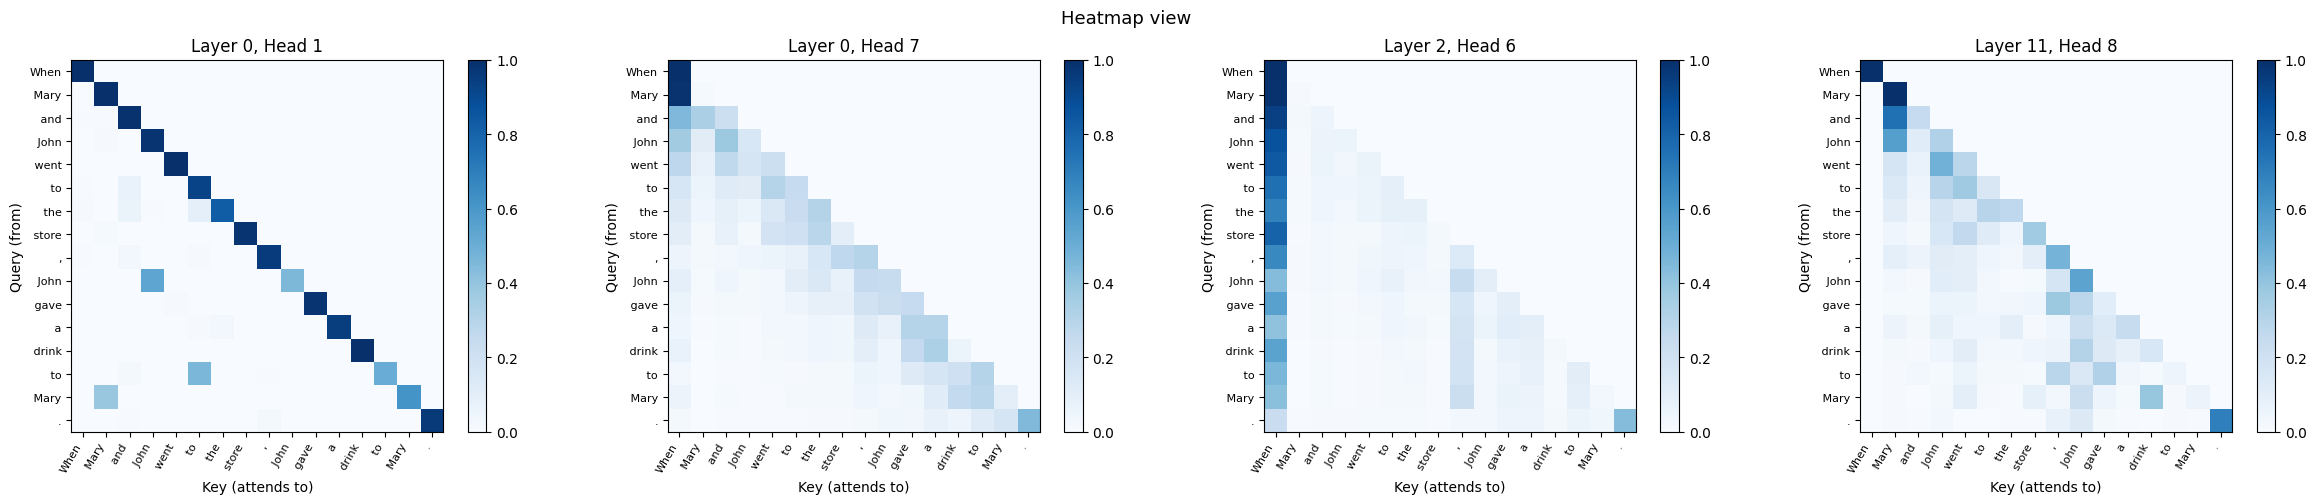

In [ ]:
# --- 4a. Classic heatmap ---

def plot_attention_heatmap(attn, tokens, layer, head, ax=None):
    """Standard heatmap of the attention matrix."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    labels = [t.replace("Ġ", " ") for t in tokens]
    weights = attn[layer, head].cpu().numpy()
    im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Key (attends to)")
    ax.set_ylabel("Query (from)")
    ax.set_title(f"Layer {layer}, Head {head}")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (l, h) in zip(axes, interesting):
    plot_attention_heatmap(attentions, tokens, l, h, ax=ax)
fig.suptitle("Heatmap view", fontsize=13)
plt.tight_layout()
plt.show()

# 4)  BertViz: Visualzing attention heads

[BertViz](https://github.com/jessevig/bertviz) (Jesse Vig)

In [ ]:
!pip install bertviz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.8 MB/s eta 0:00:00


In [ ]:
from bertviz import head_view, model_view
from transformers import GPT2Tokenizer, GPT2Model

bv_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
bv_model = GPT2Model.from_pretrained("gpt2", output_attentions=True).eval()

bv_prompt = "When Mary and John went to the store, John gave a drink to Mary."
bv_inputs = bv_tokenizer(bv_prompt, return_tensors="pt")
bv_tokens = bv_tokenizer.convert_ids_to_tokens(bv_inputs["input_ids"][0])

with torch.no_grad():
    bv_outputs = bv_model(**bv_inputs)

bv_attention = bv_outputs.attentions  # tuple of (1, n_heads, T, T)
print(f"Ready: {len(bv_attention)} layers, tokens = {bv_tokens}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready: 12 layers, tokens = ['When', 'ĠMary', 'Ġand', 'ĠJohn', 'Ġwent', 'Ġto', 'Ġthe', 'Ġstore', ',', 'ĠJohn', 'Ġgave', 'Ġa', 'Ġdrink', 'Ġto', 'ĠMary', '.']


In [ ]:
# MODEL VIEW — compact overview of every layer and head
# click any cell to see the full attention pattern
model_view(bv_attention, bv_tokens)

<IPython.core.display.Javascript object>